In [2]:
import pandas as pd


mbc_parsimonious = pd.read_csv('tmp/test.csv', usecols=range(6), index_col=False)

mbc_parsimonious = mbc_parsimonious.fillna('')

mbc_parsimonious

,Document,Speaker,ID,Particles,Bases,Fragment
0,mbc001,Hemana Waaka,mbc001.6.0.1995-04-06,e.ngā/o.te,matawaka/motu,E ngā matawaka o te motu
1,mbc001,Hemana Waaka,mbc001.6.1.1995-04-06,kia/,ora/koutou,kia ora anō rā koutou katoa.
2,mbc001,Hemana Waaka,mbc001.6.2.1995-04-06,/ā/mō,anei/tātou/wehenga/tēnei/ata,Anei rā ā tātou wehenga kōrero mō tēnei ata.
3,mbc001,Hemana Waaka,mbc001.8.0.1995-04-06,/i.te/o.te/o.te/o/ki.te/i,mai/tīmatanga/kuhu/rōpū/pōhutu/marae/whakarewa...,Mai i te tīmatanga o te kuhu atu o Te Rōpū o P...
4,mbc001,Hemana Waaka,mbc001.8.1.1995-04-06,//a.ngā/i,tērā/anō/ētahi/āwangawanga/kaumātua/roto-rua,tērā anō ētahi āwangawanga a ngā kaumātua rā i...
...,...,...,...,...,...,...
192333,mbc273,Wena Tait,mbc273.128.15.1995-10-17,,whitu,whitu
192334,mbc273,Wena Tait,mbc273.128.16.1995-10-17,,rima,rima.
192335,mbc273,Wena Tait,mbc273.128.17.1995-10-17,nō,reira,Nō reira
192336,mbc273,Wena Tait,mbc273.128.18.1995-10-17,ko//e,wena/tēnei/mihi,ko Wena [Tait] tēnei e mihi atu nei


In [3]:
import numpy as np


df = pd.DataFrame(mbc_parsimonious)
for states in ['Particles', 'Bases']:
    df[states] = df[states].str.split('/')

df['Weight'] = np.log(df['Particles'].str.len())

df = df.sample(10000, weights=df['Weight'])
df

,Document,Speaker,ID,Particles,Bases,Fragment,Weight
189932,mbc271,Wena Tait,mbc271.35.0,"[, ]","[ia, wiki]",Ia wiki,0.693147
32041,mbc076,Kairo McLean,mbc076.217.1.1995-02-28,"[mō, ngā]",[],mō ngā,0.693147
89851,mbc148,Tipene O'Regan,mbc148.75.0,"[he, o]","[tohu, tū-hawaiki]",He tohu whakamaharatanga o Tū-Hawaiki,0.693147
36038,mbc086,Kāwana Nepia,mbc086.24.8.1996-03-11,"[ko, e, , te]","[ēnei, whakaaro, kī, tēnei, āhua, papa]",Ko ēnei whakaaro e kī ai tēnei āhua te papa tā...,1.386294
171973,mbc246,Whare-huia Milroy,mbc246.9.9.1995-04-23,"[, te, ki.a, me.te, kei.te, , i, i, te]","[tēnei, anō, mihi, koutou, tūmanako, manaakiti...",tēnei anō te mihi atu ki a koutou me te tūmana...,2.197225
...,...,...,...,...,...,...,...
146783,mbc211,Lewis Moeau,mbc211.52.6.1996-03-31,"[i.te, i, a, ki.te, o]","[paraire, haere, ia, kura, whitireia]",i te Paraire nei i haere a ia ki te Kura Matat...,1.609438
187117,mbc266,Te Rangi-hau Gilbert,mbc266.88.2.1995-07-30,"[kei.te, , o, ki, o.ā, i, ki.ngā, o.te, a]","[mihi, mātou, marae, ētahi, tātou, kaituhi, ek...",Kei te mihi atu mātou o Marae ki ētahi o ā tāt...,2.197225
96978,mbc154,Joanne Waewae-Ryan,mbc154.85.12,"[e, , i, i]","[whā, mātou, roto]",e whā hoki mātou i roto i,1.386294
32112,mbc077,Tini Molyneux,mbc077.6.3.1995-03-07,"[ko.te, hei.tā]","[pā, [tom]",Ko te pā pōuri hei tā [Tom Bowling-Murray],0.693147


Note: mode of base count is right shifted relative to mode of marker count, on weighted sample. We can investigate whether this is an effect of false starts, which would increase the ratio of marker-base, or of complex phrases, which would decrease it.

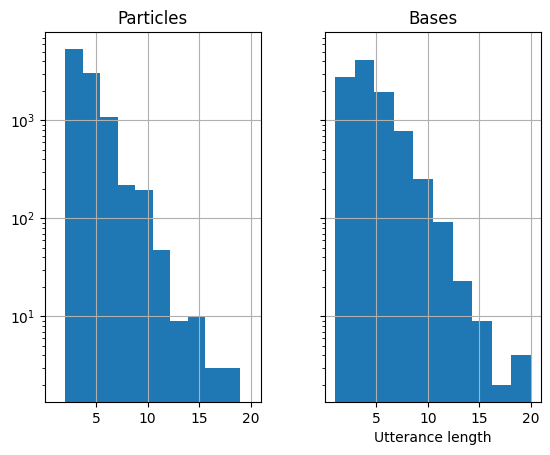

In [298]:
import matplotlib.pyplot as plt


chart = pd.DataFrame()
for states in ['Particles', 'Bases']:
    chart[states] = df[states].str.len()

chart.hist(sharex=True, sharey=True)
plt.xlabel('Utterance length')
plt.yscale('log')
plt.show()

In [5]:
import numpy as np


def get_observations(df: pd.DataFrame, col):
    observations = df[col].dropna().array
    lengths = np.array([len(i) for i in observations])
    return np.concatenate(observations), lengths

# len(pd.Series(observations).unique()), len(observations), pd.Series(lengths).mean()
observations = pd.DataFrame([(col, *get_observations(df, col)) for col in ['Particles', 'Bases']], columns=['Series', 'Items', 'Lengths']).set_index('Series')
observations

,Items,Lengths
Series,,
Particles,"[, , mō, ngā, he, o, ko, e, , te, , te, ki.a, ...","[2, 2, 2, 4, 9, 5, 4, 3, 6, 3, 2, 6, 3, 2, 6, ..."
Bases,"[ia, wiki, , tohu, tū-hawaiki, ēnei, whakaaro,...","[2, 1, 2, 6, 8, 3, 5, 3, 7, 3, 1, 7, 4, 2, 7, ..."


In [6]:
pd.DataFrame(observations.apply(lambda x: (len(x['Items']), len(pd.Series(x['Items']).unique()), pd.Series(x['Lengths']).mean()), axis=1).tolist(), columns=['Items', 'Unique', 'MeanLength'])

,Items,Unique,MeanLength
0,38287,172,3.8287
1,39436,3633,3.9436


In [301]:
observations['Items'].apply(lambda x: pd.Series(x).groupby(x).count().describe()).T

Series,Particles,Bases
count,172.000000,3633.000000
mean,222.598837,10.854941
std,666.445829,47.359311
min,1.000000,1.000000
25%,2.750000,1.000000
50%,12.000000,1.000000
75%,96.500000,4.000000
max,6165.000000,1039.000000


/Users/connortaylorbrown/Desktop/linguistics/masters/thesis/mbc-analyser/venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


array([ 5.13901604e+00,  1.39499889e-03, -8.27681391e-02])

tēnei            1.0
rātou            2.0
tātou            3.0
roto             4.0
kōrero           5.0
               ...  
[anderson]    2703.5
[ah           2703.5
[birkdale]    2703.5
[ben]         2703.5
hika          2703.5
Length: 3633, dtype: float64

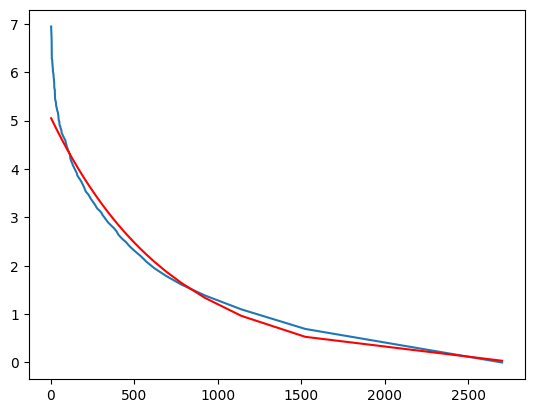

In [217]:
import numpy as np
from scipy.optimize import curve_fit


def rank(df: pd.DataFrame, col):
    items = df['Items'].T[col]
    return pd.Series(items).groupby(items).count().sort_values()


states = rank(observations, 'Bases')
log_freq = np.log(states)

def f(x, a, b, c):
    return a / np.exp(b * x) + c

order = log_freq.rank(ascending=False)
popt, _ = curve_fit(f, order, log_freq)

display(popt)
display(order.sort_values())
plt.plot(order, log_freq)
plt.plot(order, f(order, *popt), 'r-')
plt.show()

In [9]:
def to_model(df, col, f):
    order = f(col)
    id_func = np.vectorize(lambda x: order[x])
    series = df.T[col]
    return tuple(x.reshape(-1, 1) for x in (id_func(series.T['Items']).astype(int), series.T['Lengths']))


to_model(observations, 'Particles', lambda col: rank(observations, col))

(array([[6165],
        [6165],
        [ 359],
        ...,
        [  17],
        [6165],
        [6165]], shape=(38287, 1)),
 array([[2],
        [2],
        [2],
        ...,
        [4],
        [2],
        [2]], shape=(10000, 1)))

In [366]:
from hmmlearn.hmm import CategoricalHMM


particles = CategoricalHMM(n_components=4, n_iter=50)
particles.fit(*to_model(observations, 'Particles', lambda col: rank(observations, col)))

,n_components,4
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,n_features,np.int64(6166)
,algorithm,'viterbi'
,random_state,RandomState(M...at 0x10B20E340
,n_iter,50
,tol,0.01
,verbose,False
,params,'ste'


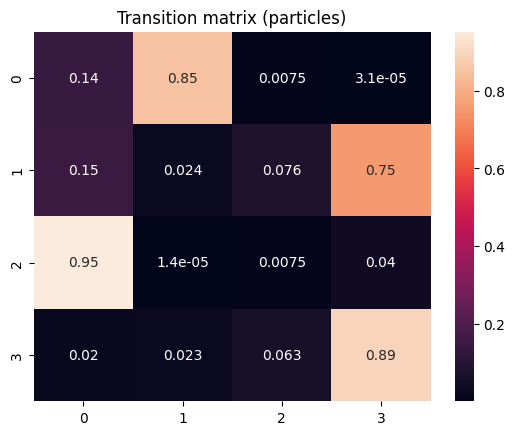

In [417]:
import seaborn as sns


sns.heatmap(particles.transmat_, annot=True)
plt.title('Transition matrix (particles)')
plt.show()

In [388]:
bases = CategoricalHMM(n_components=4, n_iter=50)
bases.fit(*to_model(observations, 'Bases', lambda col: rank(observations, col)))

,n_components,4
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,n_features,np.int64(1040)
,algorithm,'viterbi'
,random_state,RandomState(M...at 0x10B20E340
,n_iter,50
,tol,0.01
,verbose,False
,params,'ste'


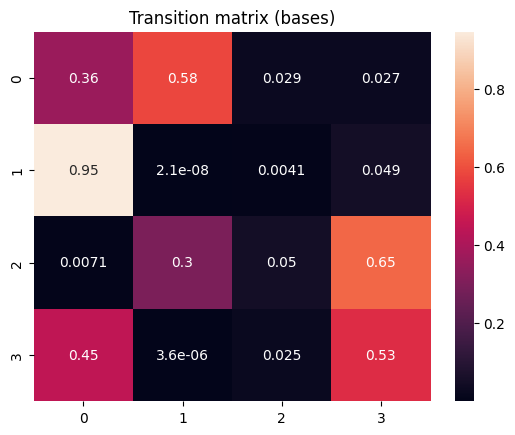

In [416]:
import seaborn as sns


sns.heatmap(bases.transmat_, annot=True)
plt.title('Transition matrix (bases)')
plt.show()

In [455]:
ex = pd.DataFrame(df[['ID', 'Particles', 'Bases', 'Fragment']])
ex

,ID,Particles,Bases,Fragment
189932,mbc271.35.0,"[, ]","[ia, wiki]",Ia wiki
32041,mbc076.217.1.1995-02-28,"[mō, ngā]",[],mō ngā
89851,mbc148.75.0,"[he, o]","[tohu, tū-hawaiki]",He tohu whakamaharatanga o Tū-Hawaiki
36038,mbc086.24.8.1996-03-11,"[ko, e, , te]","[ēnei, whakaaro, kī, tēnei, āhua, papa]",Ko ēnei whakaaro e kī ai tēnei āhua te papa tā...
171973,mbc246.9.9.1995-04-23,"[, te, ki.a, me.te, kei.te, , i, i, te]","[tēnei, anō, mihi, koutou, tūmanako, manaakiti...",tēnei anō te mihi atu ki a koutou me te tūmana...
...,...,...,...,...
146783,mbc211.52.6.1996-03-31,"[i.te, i, a, ki.te, o]","[paraire, haere, ia, kura, whitireia]",i te Paraire nei i haere a ia ki te Kura Matat...
187117,mbc266.88.2.1995-07-30,"[kei.te, , o, ki, o.ā, i, ki.ngā, o.te, a]","[mihi, mātou, marae, ētahi, tātou, kaituhi, ek...",Kei te mihi atu mātou o Marae ki ētahi o ā tāt...
96978,mbc154.85.12,"[e, , i, i]","[whā, mātou, roto]",e whā hoki mātou i roto i
32112,mbc077.6.3.1995-03-07,"[ko.te, hei.tā]","[pā, [tom]",Ko te pā pōuri hei tā [Tom Bowling-Murray]


In [456]:
def predict(model: CategoricalHMM, df: pd.DataFrame, col, f):
    order = f(col)
    id_func = np.vectorize(lambda x: order[x])
    return df.apply(lambda x: model.predict(id_func(x[col]).astype(int).reshape(1, -1)).tolist(), axis=1)

modelled = pd.DataFrame(ex[['ID', 'Fragment']])
modelled['Particles'] = predict(particles, ex, 'Particles', lambda col: rank(observations, col))
modelled['Bases'] = predict(bases, ex, 'Bases', lambda col: rank(observations, col))

modelled

,ID,Fragment,Particles,Bases
189932,mbc271.35.0,Ia wiki,"[0, 1]","[1, 0]"
32041,mbc076.217.1.1995-02-28,mō ngā,"[0, 1]",[2]
89851,mbc148.75.0,He tohu whakamaharatanga o Tū-Hawaiki,"[1, 3]","[2, 1]"
36038,mbc086.24.8.1996-03-11,Ko ēnei whakaaro e kī ai tēnei āhua te papa tā...,"[0, 1, 0, 1]","[1, 0, 0, 1, 0, 0]"
171973,mbc246.9.9.1995-04-23,tēnei anō te mihi atu ki a koutou me te tūmana...,"[0, 1, 3, 2, 0, 1, 3, 3, 3]","[2, 3, 3, 3, 3, 3, 3, 0]"
...,...,...,...,...
146783,mbc211.52.6.1996-03-31,i te Paraire nei i haere a ia ki te Kura Matat...,"[1, 3, 3, 3, 3]","[2, 3, 3, 0, 1]"
187117,mbc266.88.2.1995-07-30,Kei te mihi atu mātou o Marae ki ētahi o ā tāt...,"[0, 1, 3, 3, 3, 3, 3, 3, 3]","[2, 3, 0, 0, 1, 0, 0, 1, 0, 1]"
96978,mbc154.85.12,e whā hoki mātou i roto i,"[0, 1, 3, 3]","[2, 3, 0]"
32112,mbc077.6.3.1995-03-07,Ko te pā pōuri hei tā [Tom Bowling-Murray],"[0, 1]","[2, 3]"


In [463]:
printable = pd.DataFrame(modelled)
for col in ['Particles', 'Bases']:
    printable[col] = printable[col].apply(lambda x: '-'.join(str(i) for i in x))

printable[['ID', 'Particles', 'Bases', 'Fragment']]

,ID,Particles,Bases,Fragment
189932,mbc271.35.0,0-1,1-0,Ia wiki
32041,mbc076.217.1.1995-02-28,0-1,2,mō ngā
89851,mbc148.75.0,1-3,2-1,He tohu whakamaharatanga o Tū-Hawaiki
36038,mbc086.24.8.1996-03-11,0-1-0-1,1-0-0-1-0-0,Ko ēnei whakaaro e kī ai tēnei āhua te papa tā...
171973,mbc246.9.9.1995-04-23,0-1-3-2-0-1-3-3-3,2-3-3-3-3-3-3-0,tēnei anō te mihi atu ki a koutou me te tūmana...
...,...,...,...,...
146783,mbc211.52.6.1996-03-31,1-3-3-3-3,2-3-3-0-1,i te Paraire nei i haere a ia ki te Kura Matat...
187117,mbc266.88.2.1995-07-30,0-1-3-3-3-3-3-3-3,2-3-0-0-1-0-0-1-0-1,Kei te mihi atu mātou o Marae ki ētahi o ā tāt...
96978,mbc154.85.12,0-1-3-3,2-3-0,e whā hoki mātou i roto i
32112,mbc077.6.3.1995-03-07,0-1,2-3,Ko te pā pōuri hei tā [Tom Bowling-Murray]


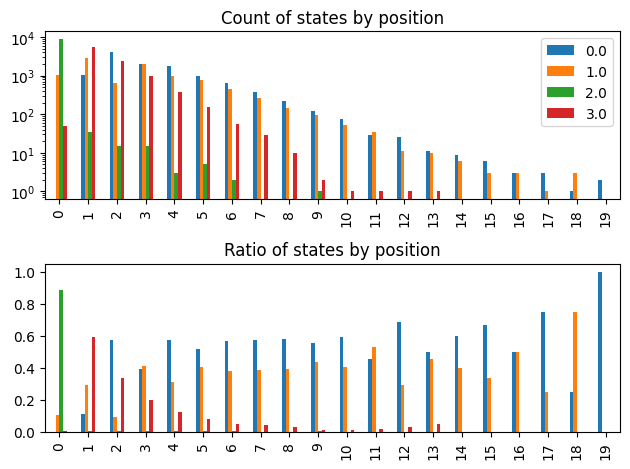

In [454]:
by_position = pd.DataFrame(modelled['Bases'].tolist()).apply(lambda x: x.value_counts(), axis=0)


fig, ax = plt.subplots(2)
ax[0].set_title('Count of states by position')
by_position.T.plot.bar(ax=ax[0])
ax[0].set_yscale('log')

ax[1].set_title('Ratio of states by position')
(by_position / by_position.sum()).T.plot.bar(ax=ax[1])
ax[1].get_legend().remove()

plt.tight_layout()

In [393]:
def find(df: pd.DataFrame, model: str, state):
    return df[model].apply(lambda x: state in x)


modelled.sort_values('Particles', ascending=False, key=lambda x: x.str.len())
modelled\
    .loc[find(ex, 'Particles', 'nā.te') & find(ex, 'Particles', 'i')]
    # .loc[modelled['Particles'].str.len() <= 4]\

,Fragment,Particles,Bases
22188,Nā te Poari Huakiwi i hāmene tētahi Māori,"[0, 0, 1]","[1, 0, 1, 0]"
26320,Nā te heamana o te Kaunihera Whakatūpato Waipi...,"[1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]","[2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, ..."
139731,nā te aroha anō o te atua ki tāna i hanga ai,"[1, 3, 3, 3]","[2, 3, 0, 0]"
48127,nā te mea i runga rātou i te,"[0, 0, 1, 3, 3]","[2, 3, 3]"
81827,Nā te aha koe i whai atu ai i tō tohu tākutata...,"[0, 1, 3, 3]","[2, 3, 3, 0]"
60237,nā te mea i ahu mai i ngā taha e rua.,"[0, 1, 3, 3]","[2, 3, 3, 3]"
140279,nā te mea e kaha ana a Tāwhiri-matea i tēnei w...,"[0, 1, 3, 3, 3, 3]","[2, 3, 0, 1, 0, 0, 1, 0]"
100234,nā te kāwana i tāhae mai te whenua,"[0, 0, 1]","[1, 0, 1]"
71118,nā te Tari Māori tēnei i whakahaere ki runga i...,"[0, 1, 3, 3, 3]","[2, 1, 0, 1, 0]"
159859,Kei te tatari tonu koe kia ngau ō niho ki te i...,"[0, 1, 0, 1, 3, 3, 3]","[2, 3, 0, 1, 0, 1, 0]"


In [ ]:
def tag(col):
    total = {}
    for keys, states in zip(ex[col], modelled[col]):
        for k, state in zip(keys, states):
            states = total.get(k)
            if not states:
                states = {}
                total[k] = states
            
            c = states.get(state)
            if not c:
                states[state] = 0
            
            states[state] += 1
    
    return total
        

states = pd.DataFrame.from_dict(tag('Bases')).T
states

,1,3,2,0
ia,115.0,299.0,32.0,NaN
mea,NaN,232.0,193.0,61.0
kite,NaN,17.0,69.0,27.0
haere,NaN,132.0,163.0,110.0
riro,NaN,7.0,28.0,22.0


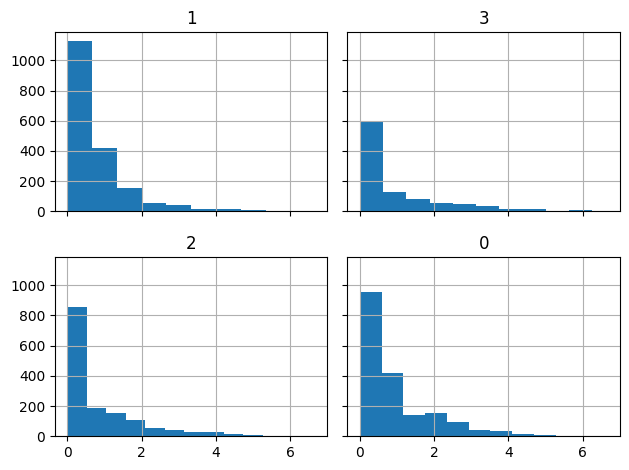

In [405]:
np.log(states).hist(sharex=True, sharey=True)
plt.tight_layout()

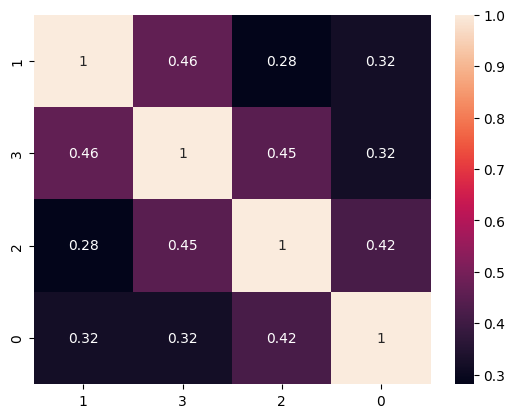

In [406]:
import seaborn as sns


sns.heatmap(states.corr(), annot=True)
plt.show()

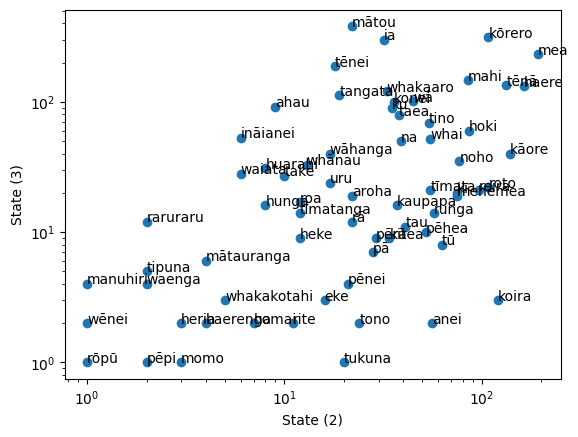

In [407]:
def annotate(df: pd.DataFrame, x, y):
    for i, row in df.iterrows():
        plt.annotate(i, (row[x], row[y]))


filtered = states.sample(100, weights=states.sum(axis=1)).fillna(0)

x = 2
y = 3

plt.scatter(x=filtered[x], y=filtered[y])
annotate(filtered, x, y)

plt.xlabel(f'State ({x})')
plt.ylabel(f'State ({y})')
plt.xscale('log')
plt.yscale('log')
plt.show()

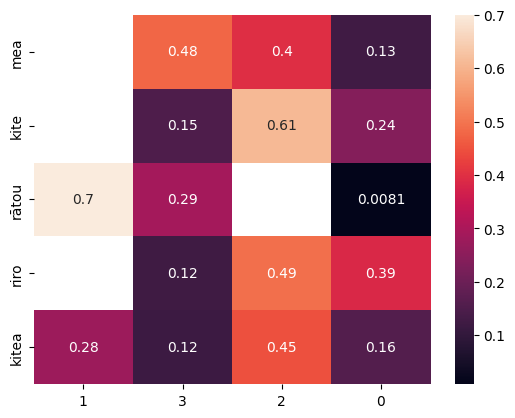

In [436]:
ratio = states.div(states.sum(axis=1), axis=0)
# filtered = ratio
filtered = ratio.loc[ratio.index.isin(['riro','rātou','mea','kitea','kite'])]

sns.heatmap(filtered, annot=True)
plt.show()

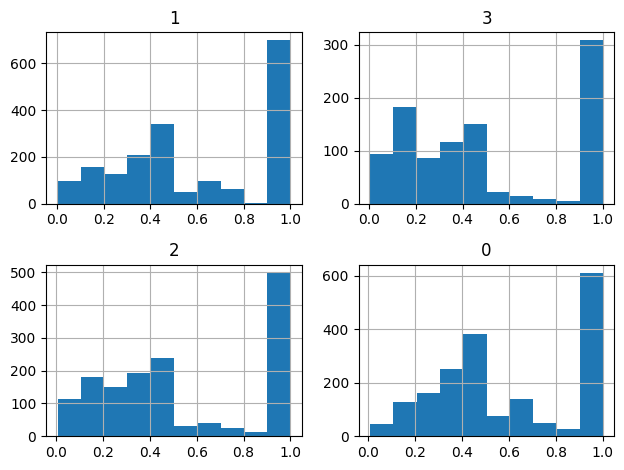

In [433]:
ratio.hist()
plt.tight_layout()

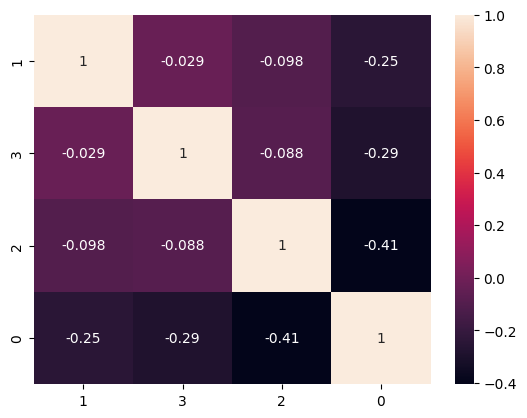

In [409]:
sns.heatmap(ratio.corr(), annot=True)
plt.show()

In [410]:
summary = pd.DataFrame(ratio)
summary['Weight'] = states.sum(axis=1)
sv = pd.read_csv('input/sv.txt', header=None).set_index(0)
summary['Stative'] = summary.index.isin(sv.index)

summary.reset_index()

,index,1,3,2,0,Weight,Stative
0,ia,0.257848,0.670404,0.071749,NaN,446.0,False
1,wiki,0.184211,0.039474,0.078947,0.697368,76.0,False
2,,NaN,NaN,1.000000,NaN,105.0,False
3,tohu,0.301887,NaN,0.113208,0.584906,53.0,False
4,tū-hawaiki,0.750000,NaN,NaN,0.250000,4.0,False
...,...,...,...,...,...,...,...
3628,koineki,NaN,NaN,1.000000,NaN,1.0,False
3629,tāne-tino-rau,1.000000,NaN,NaN,NaN,1.0,False
3630,rua-pūhā,1.000000,NaN,NaN,NaN,1.0,False
3631,taetae,NaN,1.000000,NaN,NaN,1.0,False


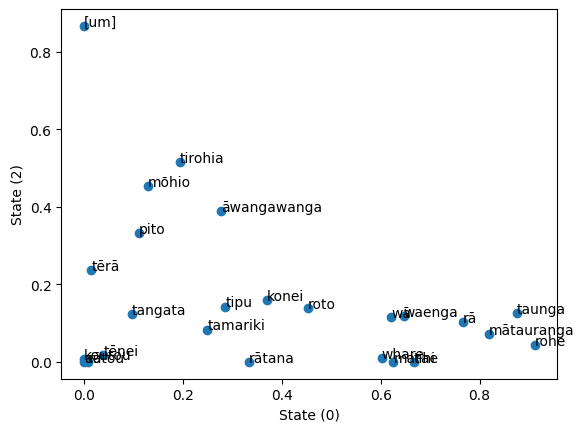

In [452]:
x = 0
y = 2

filtered = ratio.sample(25, weights=states.sum(axis=1)).fillna(0)
plt.scatter(x=filtered[x], y=filtered[y])
annotate(filtered, x, y)
plt.xlabel(f'State ({x})')
plt.ylabel(f'State ({y})')
plt.show()

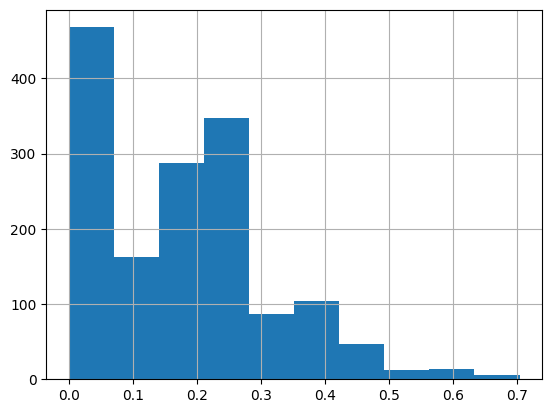

In [412]:
sd = states.div(states.sum(axis=1), axis=0).std(axis=1)
sd.hist()
plt.show()

np.float64(0.4624503599232236)

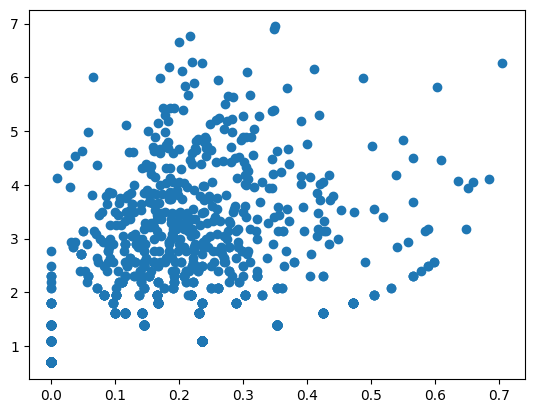

In [413]:
log_count = np.log(states.sum(axis=1))
display(sd.corr(log_count))
plt.scatter(x=sd, y=log_count)
plt.show()